# 02 – EDA: Student Depression Dataset

Utforskande dataanalys inför modellering. Bygger på det **rensade och kodade** datasetet från
`01_Dataforberedelse.ipynb` (`student_depression_clean.csv`) - saknade värden, smutsig data och
irrelevanta kolumner är redan hanterade där.

Mål: förstå distributionerna och vilka variabler som verkar hänga ihop med `Depression`.

In [1]:
import pandas as pd                # DataFrames - tabellhantering
import numpy as np                 # numeriska beräkningar
import matplotlib.pyplot as plt    # plottbibliotek
import seaborn as sns              # visualisering ovanpå matplotlib

sns.set_theme(style="whitegrid")            # global rutnätsstil
pd.set_option("display.max_columns", None)  # visa alla kolumner i output

## Visuell stil

Sätter en gemensam färgpalett och stil en gång här - alla diagram i resten av notebooken
ärver den automatiskt, så vi slipper styla om varje cell för sig.

In [2]:
# Fast, återanvändbar färgpalett - ett blå/röd-par som är valt för att gå att skilja
# på även för färgblinda.
PALETTE = {
    "blue": "#2a78d6",     # serie 1 / ena polen i diverging-skalor
    "red": "#e34948",      # serie 2 / andra polen i diverging-skalor
    "orange": "#eb6834",   # serie 3
    "neutral": "#f0efec",  # mittpunkt i diverging-skalor
    "grid": "#e1e0d9",     # hårfina gridlines
    "ink": "#0b0b0b",      # primär textfärg
    "muted": "#898781",    # sekundär text (oanvänd för axel-siffror, se nedan)
    "surface": "#fcfcfb",  # bakgrund
}

# Sätts EN gång, gäller sedan automatiskt för alla diagram nedan.
plt.rcParams.update({
    "figure.facecolor": PALETTE["surface"],
    "axes.facecolor": PALETTE["surface"],
    "axes.edgecolor": PALETTE["grid"],
    "axes.grid": True,
    "grid.color": PALETTE["grid"],
    "grid.linewidth": 0.8,
    "axes.spines.top": False,     # bort med onödiga ramlinjer
    "axes.spines.right": False,
    "text.color": PALETTE["ink"],
    "axes.labelcolor": PALETTE["ink"],
    "xtick.color": PALETTE["ink"],   # svart för kontrast
    "ytick.color": PALETTE["ink"],   # svart för kontrast
    "font.family": "sans-serif",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.titlelocation": "left",
    "figure.dpi": 200,   # skarp rendering
    "savefig.dpi": 200,
})

sns.set_palette([PALETTE["blue"], PALETTE["red"], PALETTE["orange"]])

## 1. Ladda in datan

In [3]:
df = pd.read_csv("student_depression_clean.csv")  # det REDAN RENSADE datasetet
print(df.shape)
df.head()  # Gender, Sleep Duration m.fl. är redan siffror - se kodningsnyckeln nedan

(27842, 13)


,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,33.0,Visakhapatnam,5.0,8.97,2.0,2,3,1,3.0,1.0,0,1
1,0,24.0,Bangalore,2.0,5.90,5.0,2,2,0,3.0,2.0,1,0
2,1,31.0,Srinagar,3.0,7.03,5.0,1,3,0,9.0,1.0,1,0
3,0,28.0,Varanasi,3.0,5.59,2.0,3,2,1,4.0,5.0,1,1
4,0,25.0,Jaipur,4.0,8.13,3.0,2,2,1,1.0,1.0,0,0


### Kodningsnyckel

Kategoriska variabler kodades om till siffror i `01_Dataforberedelse.ipynb`. Referens för att tolka
värdena i resten av denna notebook (t.ex. i korstabellerna nedan):

| Kolumn | 0 | 1 | 2 | 3 | 4 |
|---|---|---|---|---|---|
| `Gender` | Female | Male | | | |
| `Have you ever had suicidal thoughts ?` | No | Yes | | | |
| `Family History of Mental Illness` | No | Yes | | | |
| `Dietary Habits` | | Unhealthy | Moderate | Healthy | |
| `Sleep Duration` | | Less than 5h | 5-6h | 7-8h | More than 8h |

`City` lämnades som text (för hög kardinalitet för enkel kodning i detta steg).

In [4]:
# Datatyp + antal icke-tomma värden per kolumn - snabb koll på saknade värden/fel typer.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27842 entries, 0 to 27841
Data columns (total 13 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27842 non-null  int64  
 1   Age                                    27842 non-null  float64
 2   City                                   27842 non-null  str    
 3   Academic Pressure                      27842 non-null  float64
 4   CGPA                                   27842 non-null  float64
 5   Study Satisfaction                     27842 non-null  float64
 6   Sleep Duration                         27842 non-null  int64  
 7   Dietary Habits                         27842 non-null  int64  
 8   Have you ever had suicidal thoughts ?  27842 non-null  int64  
 9   Work/Study Hours                       27842 non-null  float64
 10  Financial Stress                       27842 non-null  float64
 11  Family Histor

## 2. Saknade värden & extremvärden

In [5]:
missing = df.isnull().sum()
missing[missing > 0]  # bör vara TOM - redan hanterat i 01_Dataforberedelse

Series([], dtype: int64)

In [6]:
# Statistik (medel, std, min/max, kvartiler) för numeriska kolumner - upptäck extremvärden.
df.describe(include="number")

,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
count,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000,27842.000000
mean,0.557252,25.820667,3.141656,7.656027,2.944149,2.399253,1.904605,0.632821,7.158286,3.140435,0.484161,0.585554
std,0.496720,4.906187,1.381729,1.470880,1.360890,1.126845,0.796905,0.482045,3.707158,1.437076,0.499758,0.492635
min,0.000000,18.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,21.000000,2.000000,6.290000,2.000000,1.000000,1.000000,0.000000,4.000000,2.000000,0.000000,0.000000
50%,1.000000,25.000000,3.000000,7.770000,3.000000,2.000000,2.000000,1.000000,8.000000,3.000000,0.000000,1.000000
75%,1.000000,30.000000,4.000000,8.920000,4.000000,3.000000,3.000000,1.000000,10.000000,4.000000,1.000000,1.000000
max,1.000000,59.000000,5.000000,10.000000,5.000000,4.000000,3.000000,1.000000,12.000000,5.000000,1.000000,1.000000


In [7]:
# Samma sak för TEXT-kolumner: antal unika värden, vanligaste värdet ("top") m.m.
df.describe(include="object")

/var/folders/7b/kbzrw4d15z3dj4gwlkzpj39w0000gn/T/ipykernel_68114/2171794019.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,City
count,27842
unique,30
top,Kalyan
freq,1569


## 3. Kolumner som redan hanterats

`Profession`, `Work Pressure`, `Job Satisfaction`, `Degree` och `id` var mest tomma/irrelevanta
(majoriteten i datasetet är heltidsstudenter) och droppades redan i `01_Dataforberedelse.ipynb`.

## 4. Målvariabeln: balans

In [8]:
# normalize=True ger ANDELAR istället för antal - kollar om målvariabeln är balanserad.
df["Depression"].value_counts(normalize=True)

Depression
1    0.585554
0    0.414446
Name: proportion, dtype: float64

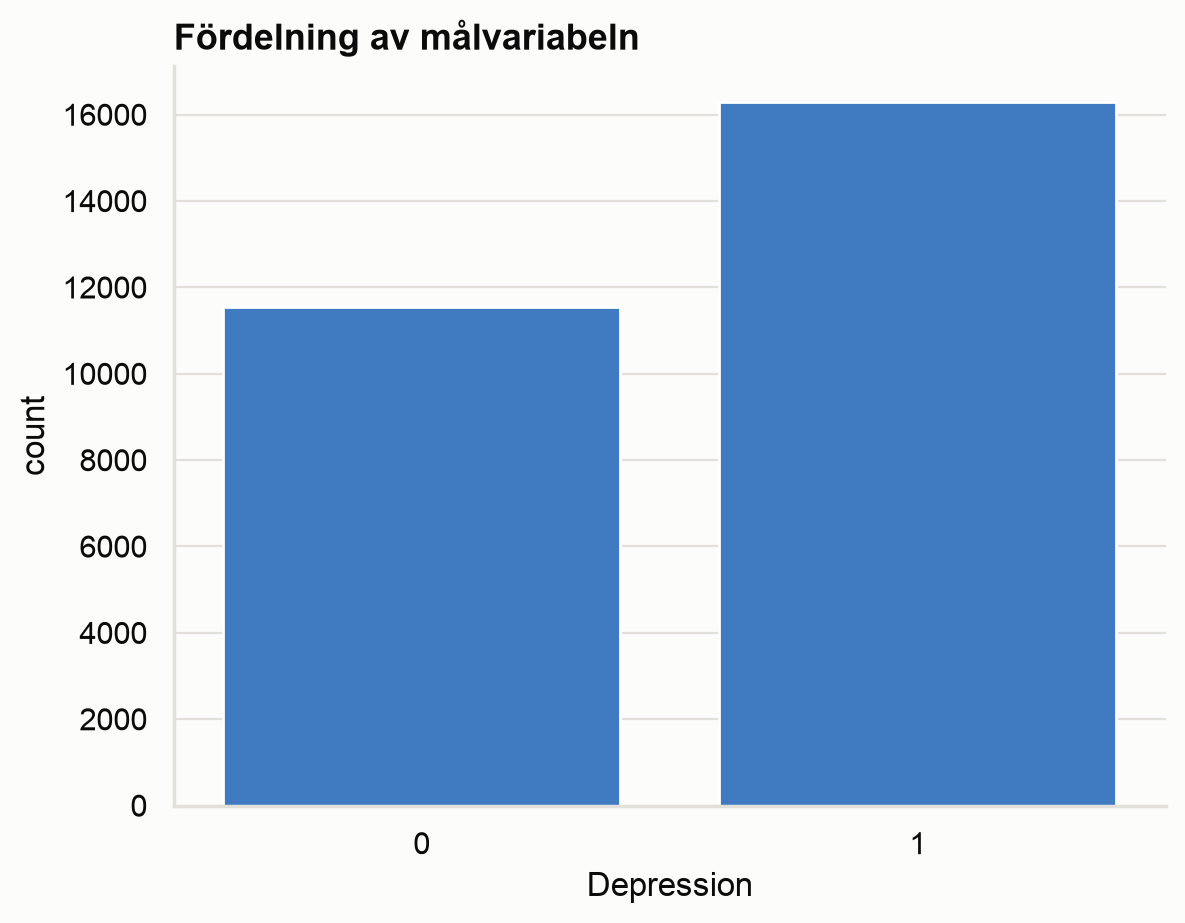

In [9]:
# Samma info som ovan, som stapeldiagram.
sns.countplot(data=df, x="Depression")
plt.title("Fördelning av målvariabeln")
plt.show()

## 5. Korrelationsöversikt

Första konkreta spadtaget: en heatmap över alla numeriska/kodade variabler, för att se
vad som hänger ihop med `Depression` (och med varandra) innan vi djupdyker i enskilda variabler.

**OBS:** korrelation fångar bara *linjära* samband - en låg siffra utesluter inte ett
verkligt mönster (se t.ex. Sleep Duration längre fram). Heatmapen är en kompass för var
vi ska titta närmare, inte facit.

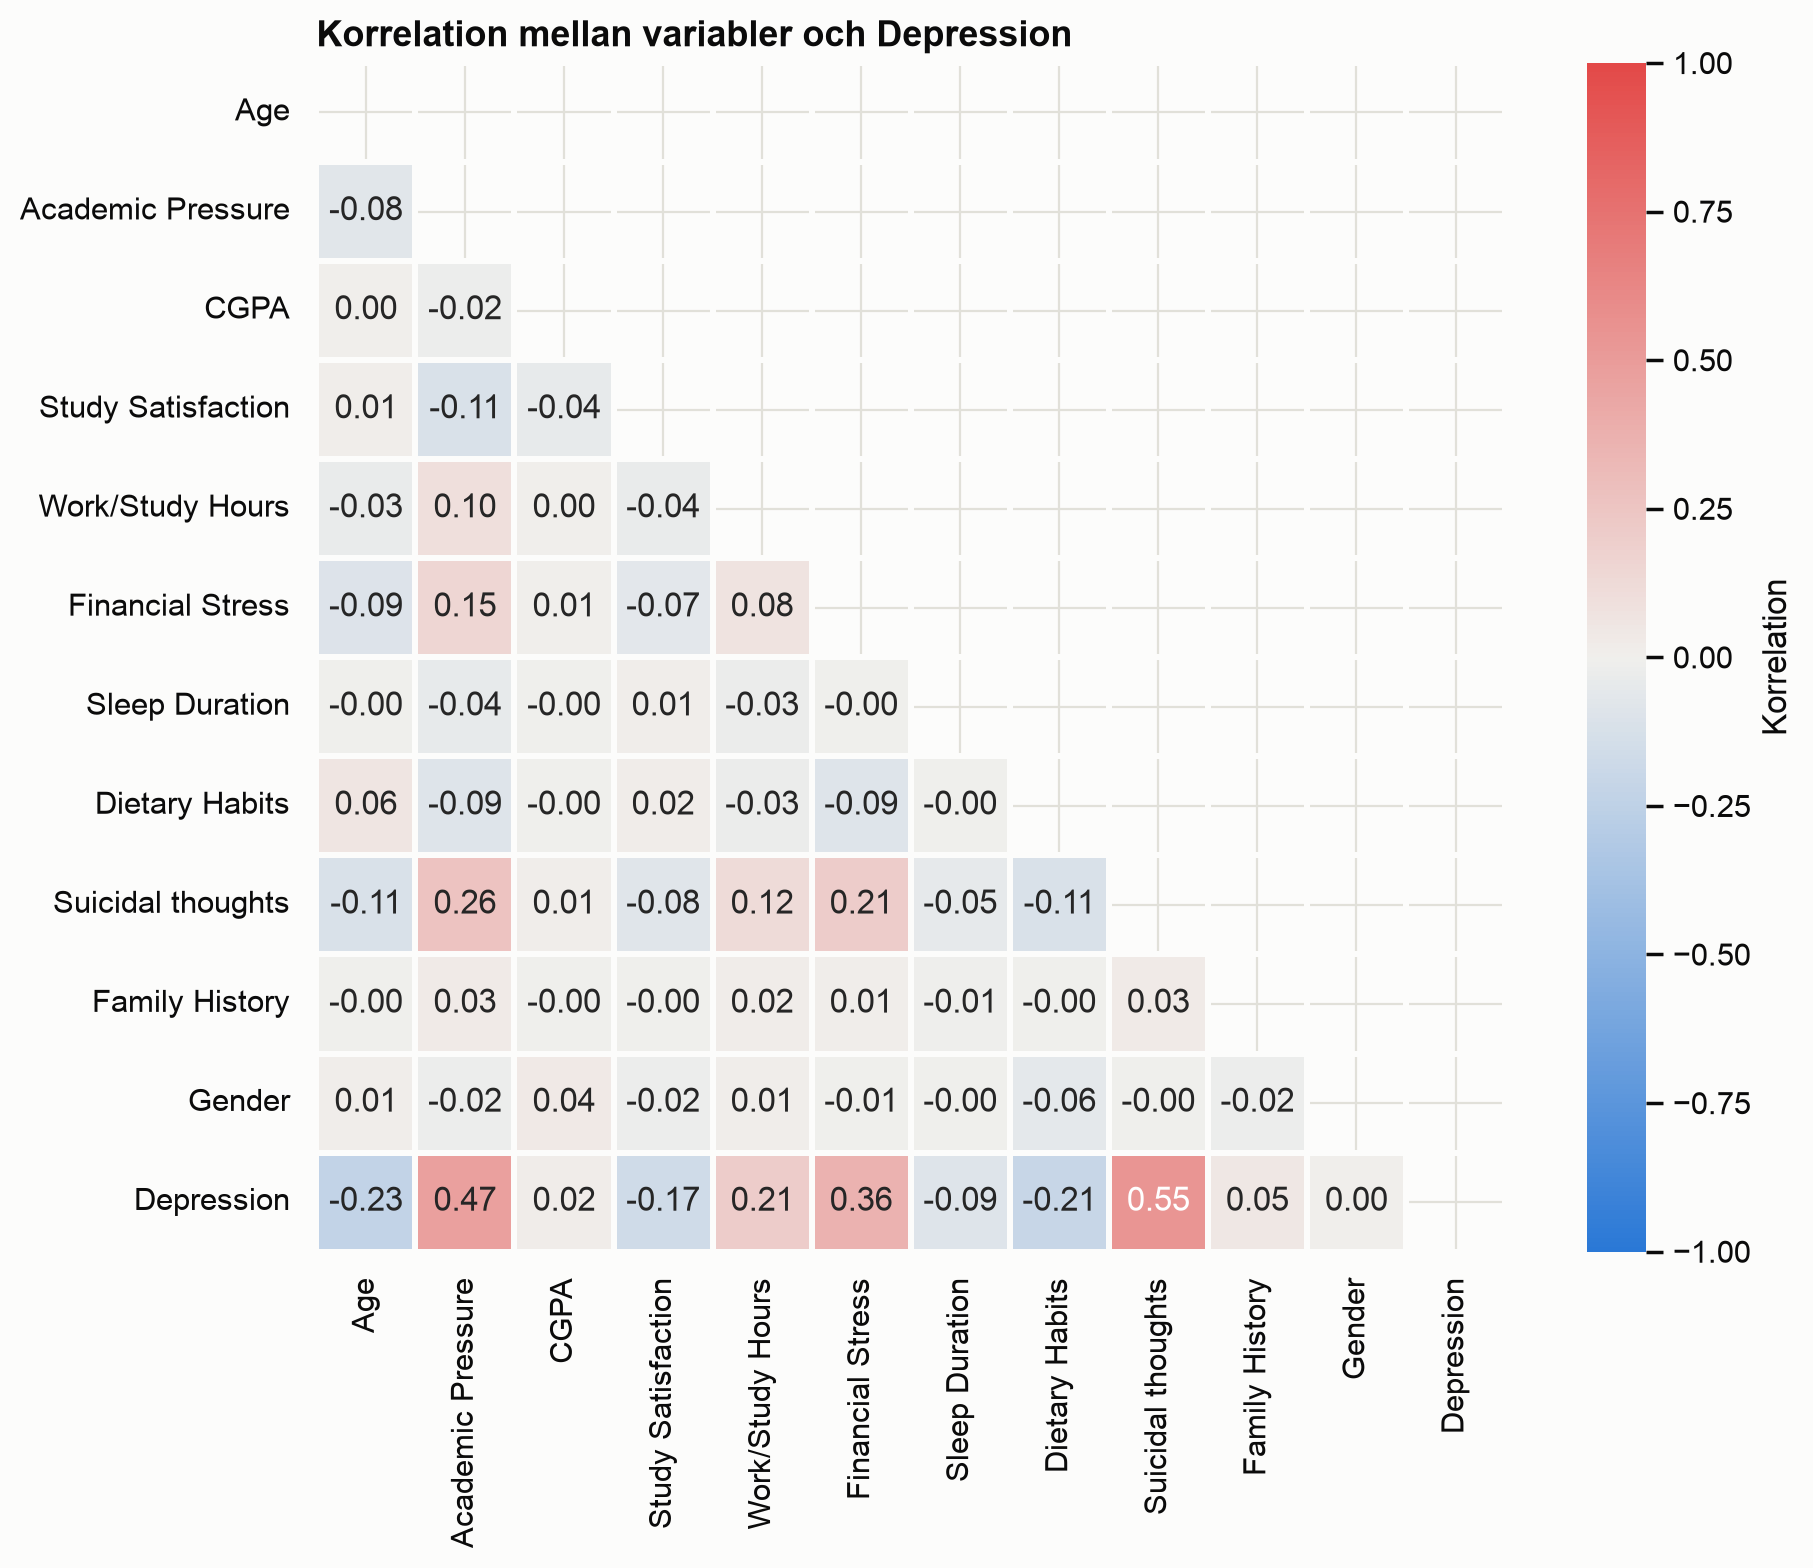

In [10]:
from matplotlib.colors import LinearSegmentedColormap

numeric_cols = [
    "Age", "Academic Pressure", "CGPA", "Study Satisfaction", "Work/Study Hours",
    "Financial Stress", "Sleep Duration", "Dietary Habits",
    "Have you ever had suicidal thoughts ?", "Family History of Mental Illness",
    "Gender",
]
corr = df[numeric_cols + ["Depression"]].corr(numeric_only=True)

# Kortare visningsnamn bara för diagrammet - datan/df:n ändras inte.
short_labels = {
    "Have you ever had suicidal thoughts ?": "Suicidal thoughts",
    "Family History of Mental Illness": "Family History",
}
corr = corr.rename(index=short_labels, columns=short_labels)

# Diverging skala (blå -> neutral -> röd) eftersom 0 är en meningsfull mittpunkt.
brand_diverging = LinearSegmentedColormap.from_list(
    "brand_diverging", [PALETTE["blue"], PALETTE["neutral"], PALETTE["red"]]
)

# Matrisen är symmetrisk - döljer övre triangeln för att slippa visa samma info två gånger.
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt=".2f",
    cmap=brand_diverging, center=0, vmin=-1, vmax=1,
    linewidths=2, linecolor=PALETTE["surface"],
    square=True,
    cbar_kws={"label": "Korrelation"},
    ax=ax,
)
ax.set_title("Korrelation mellan variabler och Depression")
plt.tight_layout()
plt.show()

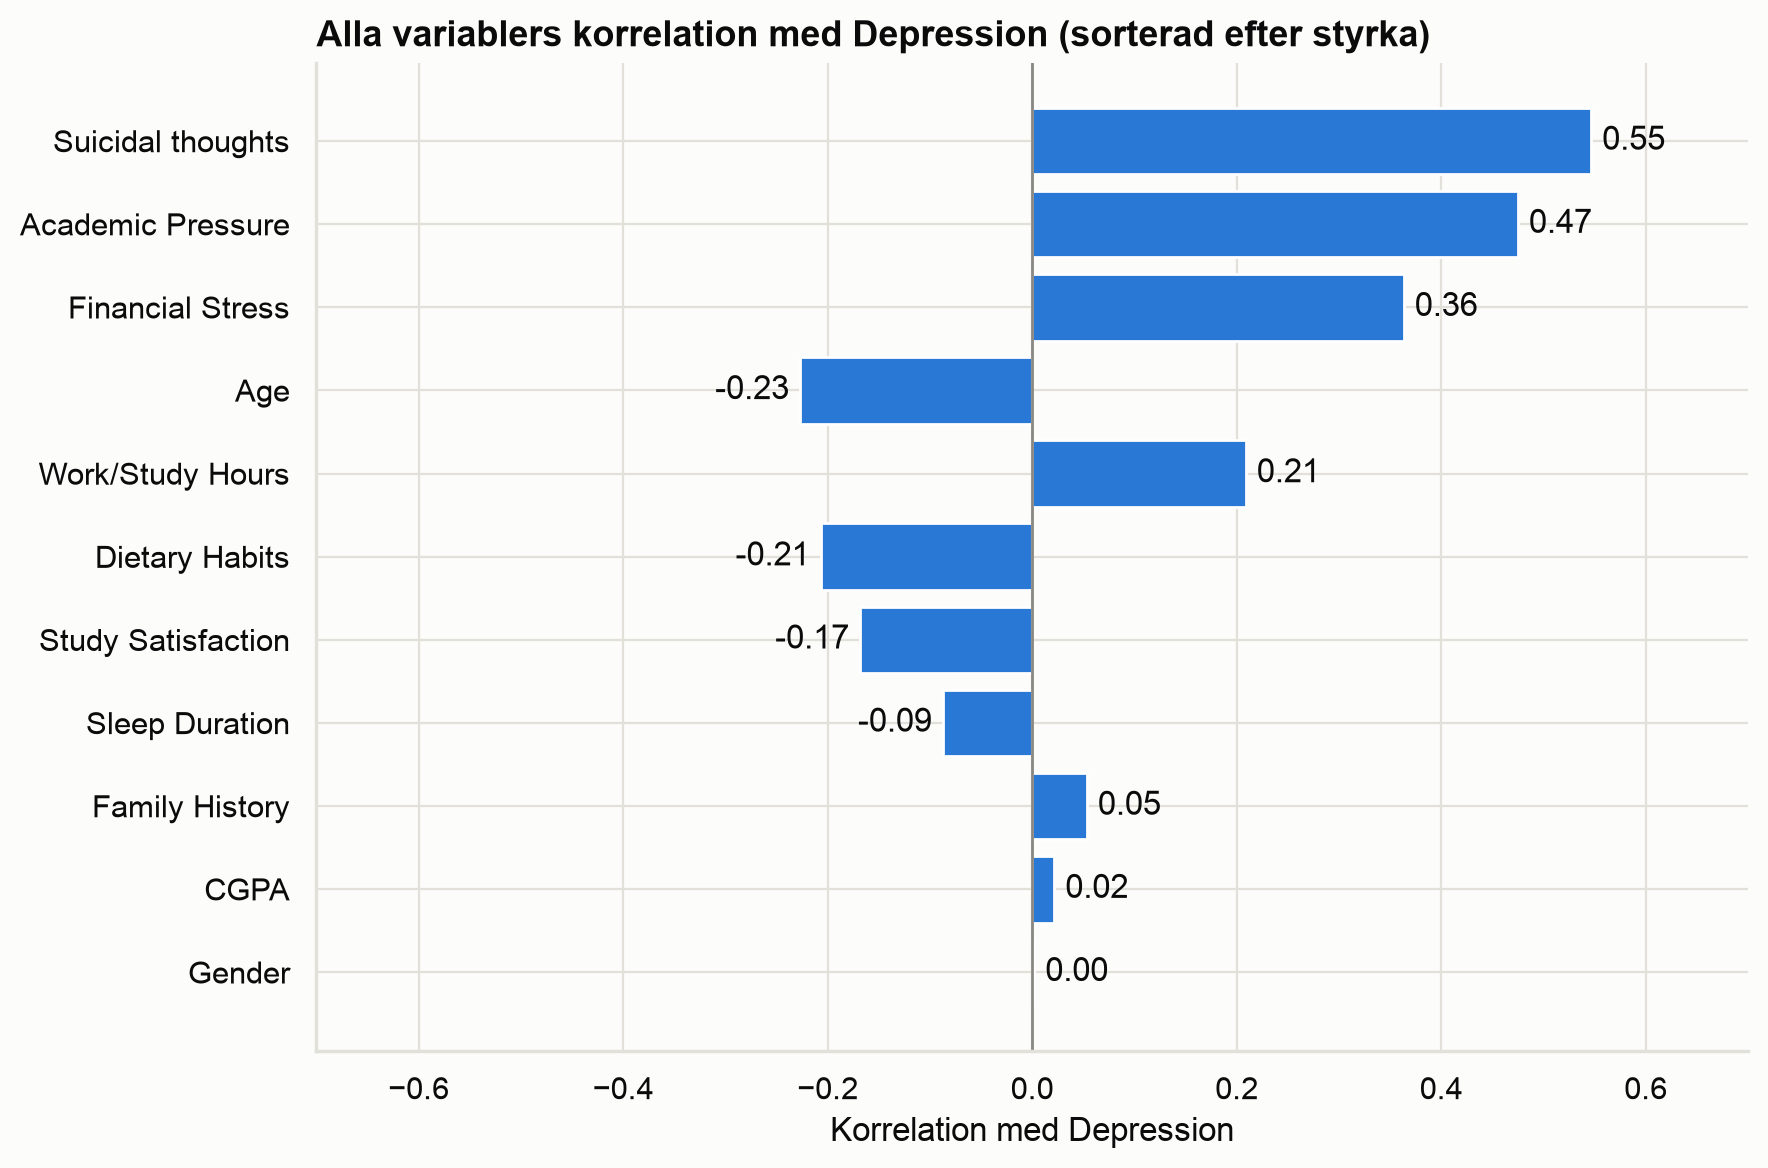

In [11]:
# Samma siffror som i heatmapens nedersta rad, men utplockade och sorterade efter
# absolutvärde - så att ingen variabel missas när man läser av. Sorterat på |korrelation|
# eftersom tecknet visar riktning, medan storleken visar styrka.
corr_depression = corr["Depression"].drop("Depression").sort_values(key=abs)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(corr_depression.index, corr_depression.values, color=PALETTE["blue"])
ax.bar_label(bars, fmt="%.2f", padding=4, color=PALETTE["ink"])
ax.axvline(0, color=PALETTE["muted"], linewidth=1)  # nollinje - skiljer positiva från negativa
ax.set_xlabel("Korrelation med Depression")
ax.set_title("Alla variablers korrelation med Depression (sorterad efter styrka)")
ax.set_xlim(-0.7, 0.7)
plt.tight_layout()
plt.show()

## 6. Academic Pressure & Financial Stress

Våra två starkaste variabler, om vi bortser från Suicidal thoughts (den läggs åt sidan -
se `Slutsatser` för varför den är för nära kopplad till själva depressionsdiagnosen för
att räknas som en bra förklarande variabel). Två separata diagram, ett per variabel, så
vart och ett är enkelt att läsa på egen hand.

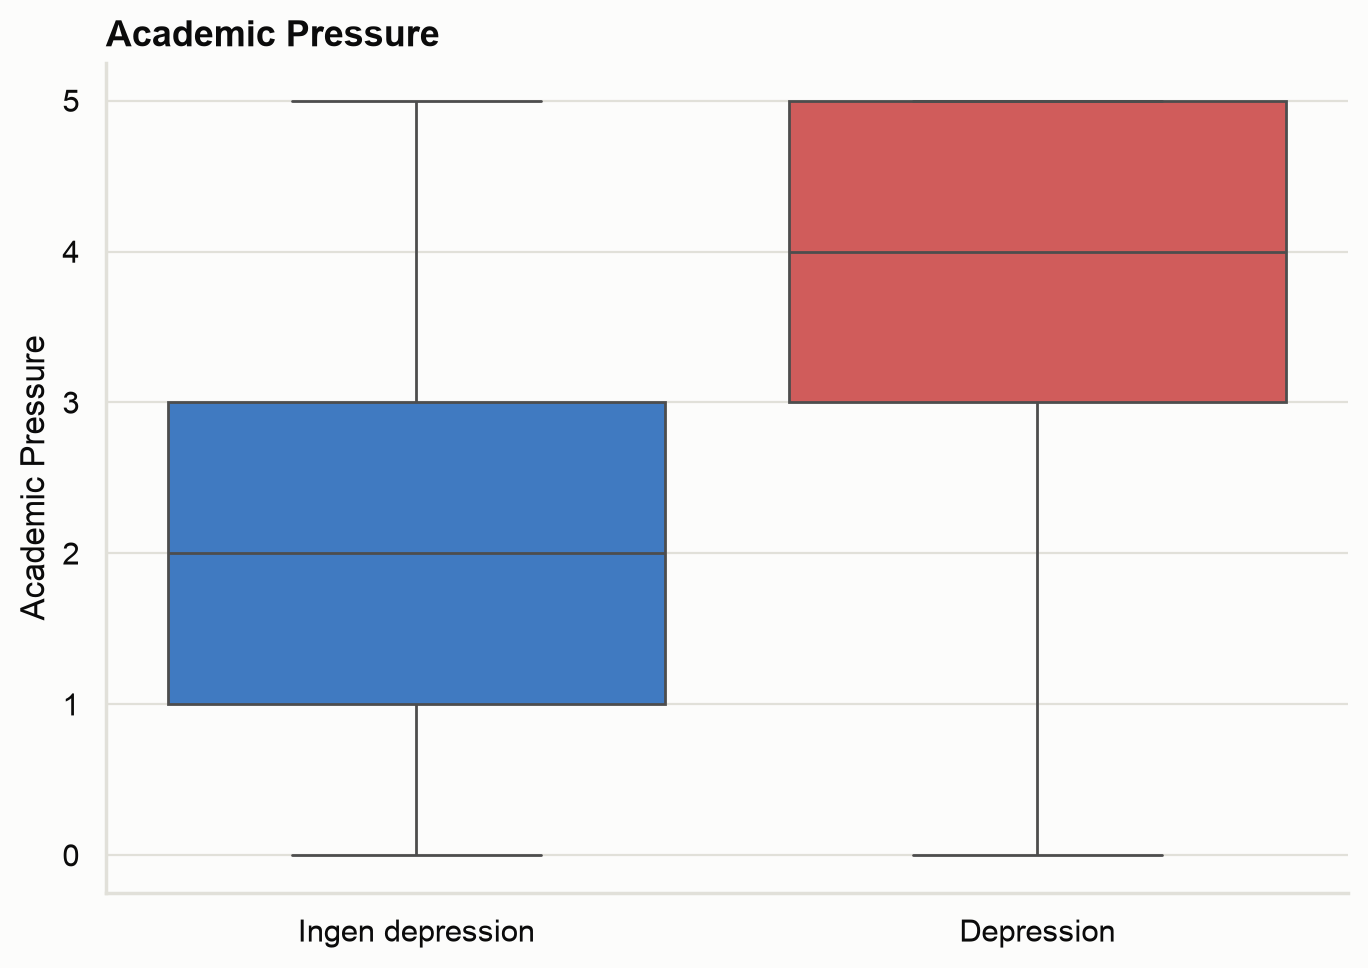

In [12]:
# Boxplot: Academic Pressure per Depression-grupp. Färgerna kommer från temacellens palett.
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="Depression", y="Academic Pressure", hue="Depression", legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Ingen depression", "Depression"])
ax.set_xlabel("")
ax.set_title("Academic Pressure")
plt.tight_layout()
plt.show()

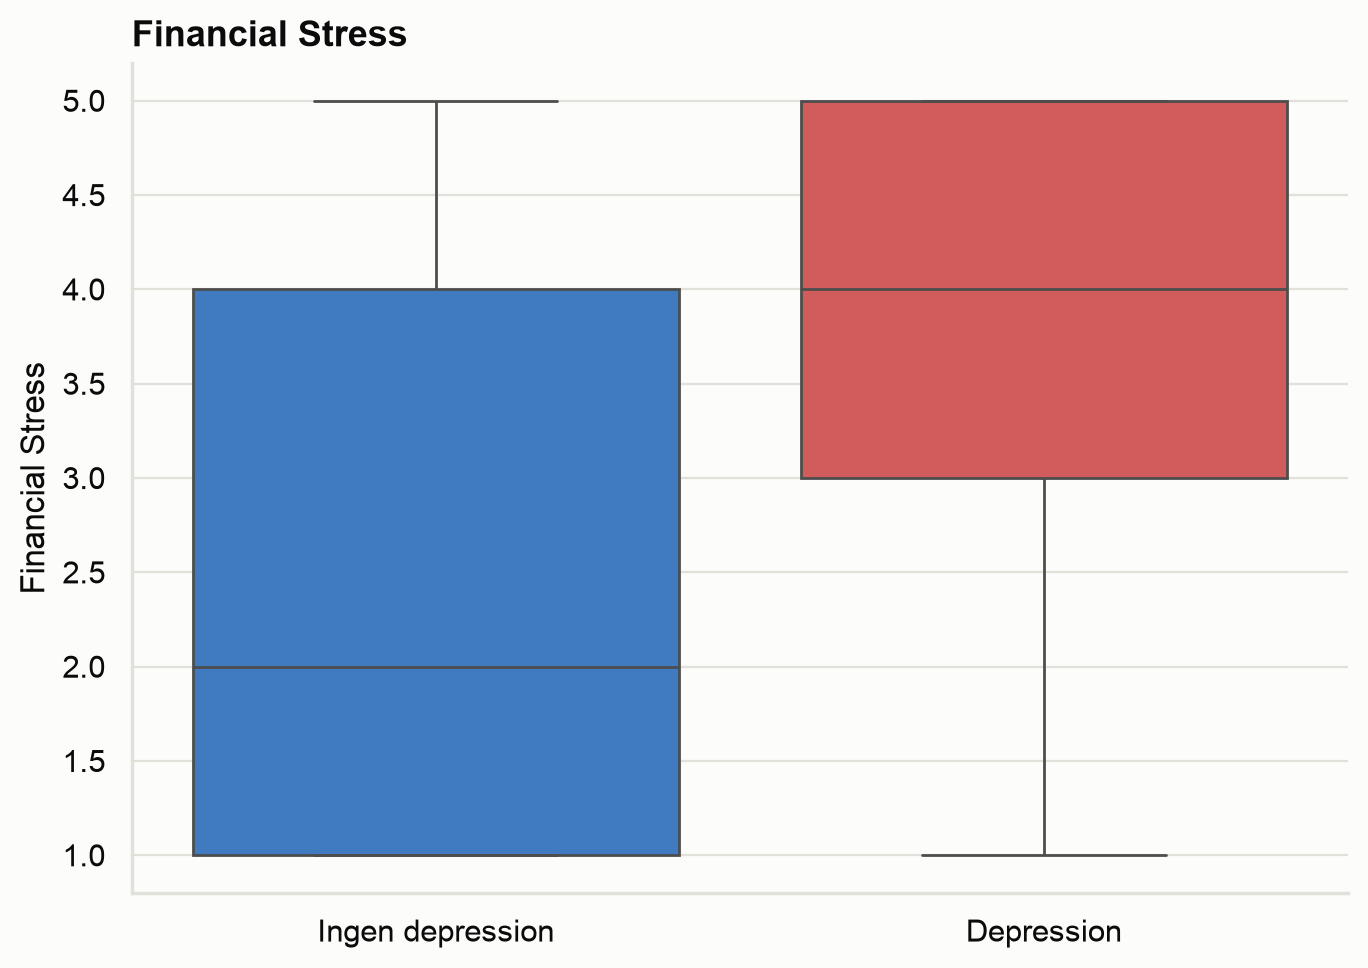

In [13]:
# Samma uppställning för Financial Stress.
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="Depression", y="Financial Stress", hue="Depression", legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Ingen depression", "Depression"])
ax.set_xlabel("")
ax.set_title("Financial Stress")
plt.tight_layout()
plt.show()

## 7. Sleep Duration, Dietary Habits, Work/Study Hours & Family History

De återstående måttliga/svaga variablerna från heatmapen har hittills bara synts som
siffror - aldrig visualiserats. Fyra diagram, samma stil (palett/rcParams) som redan
är satt ovan i "Visuell stil".

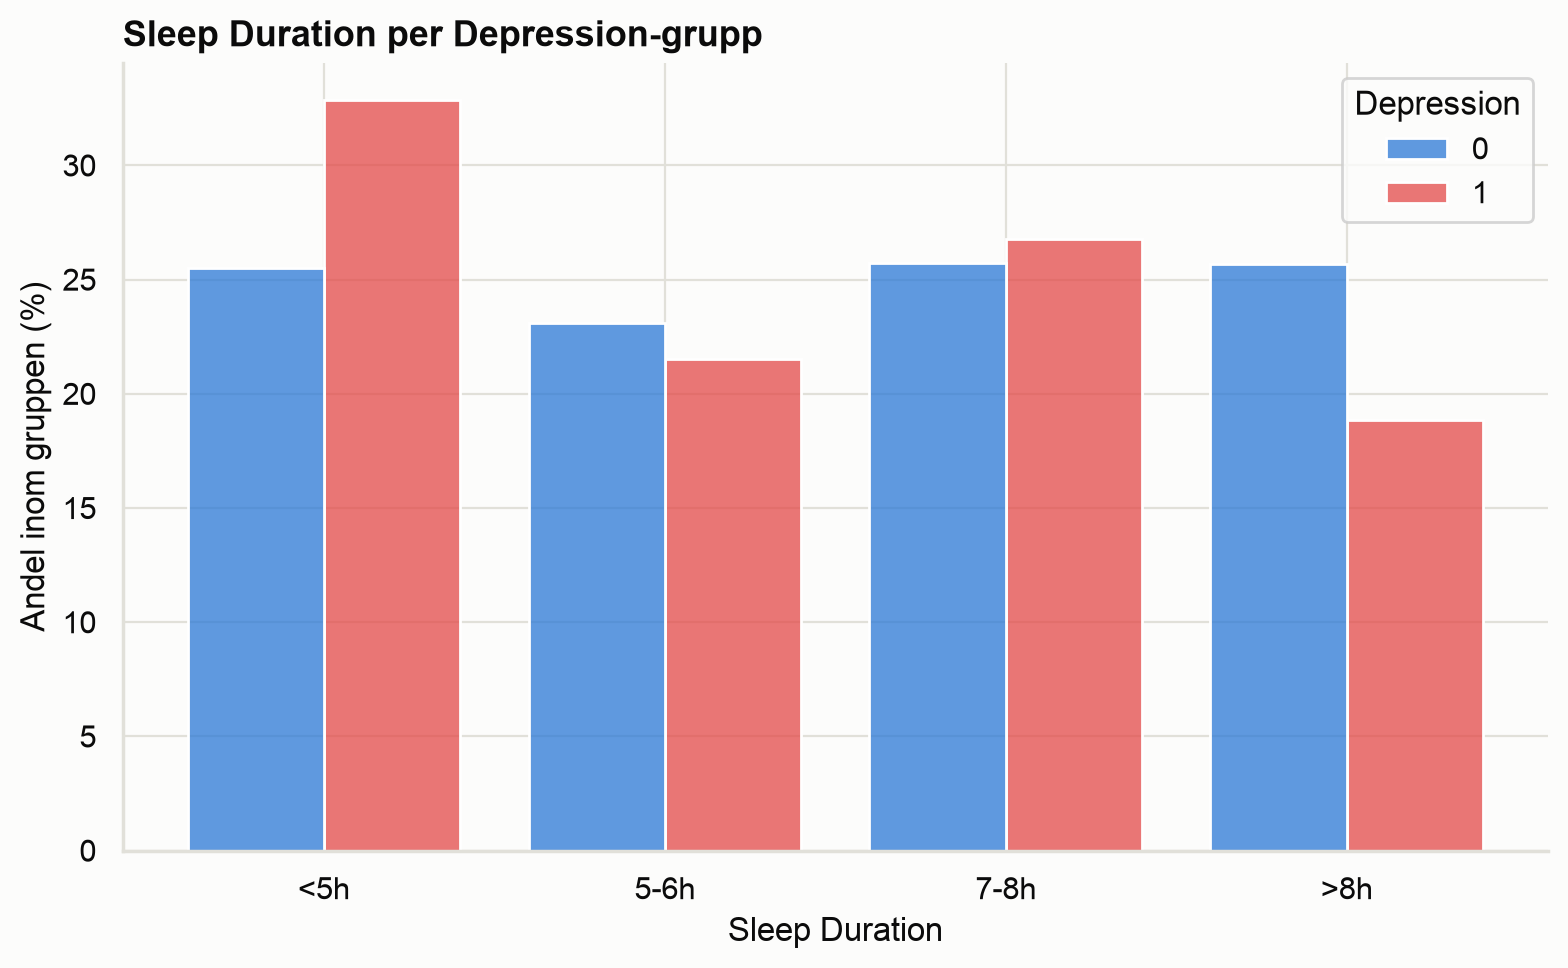

In [14]:
# Sleep Duration (1=<5h, 2=5-6h, 3=7-8h, 4=>8h): fördelning INOM varje Depression-grupp.
# Ett vanligt countplot räknar bara antal, vilket blir missvisande här eftersom grupperna
# är olika stora. Vi använder histplot med stat="percent", common_norm=False istället -
# ser likadant ut, men räknar procent inom varje grupp för sig.
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=df, x="Sleep Duration", hue="Depression",
    stat="percent", common_norm=False, discrete=True, multiple="dodge", shrink=0.8,
    ax=ax,
)
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(["<5h", "5-6h", "7-8h", ">8h"])
ax.set_ylabel("Andel inom gruppen (%)")
ax.set_title("Sleep Duration per Depression-grupp")
plt.tight_layout()
plt.show()

**Mönstret:** bland de UTAN depression är sömnen ganska jämnt spridd över alla fyra
kategorierna (~24-26% vardera). Bland de MED depression är fördelningen skevare mot
lite sömn: 32.8% sover under 5h, mot bara 18.9% som sover över 8h. Gruppen med
depression är alltså mer koncentrerad till lite-sömn-änden - även om spridningen
totalt sett är måttlig (i linje med den svaga korrelationen vi såg i heatmapen).

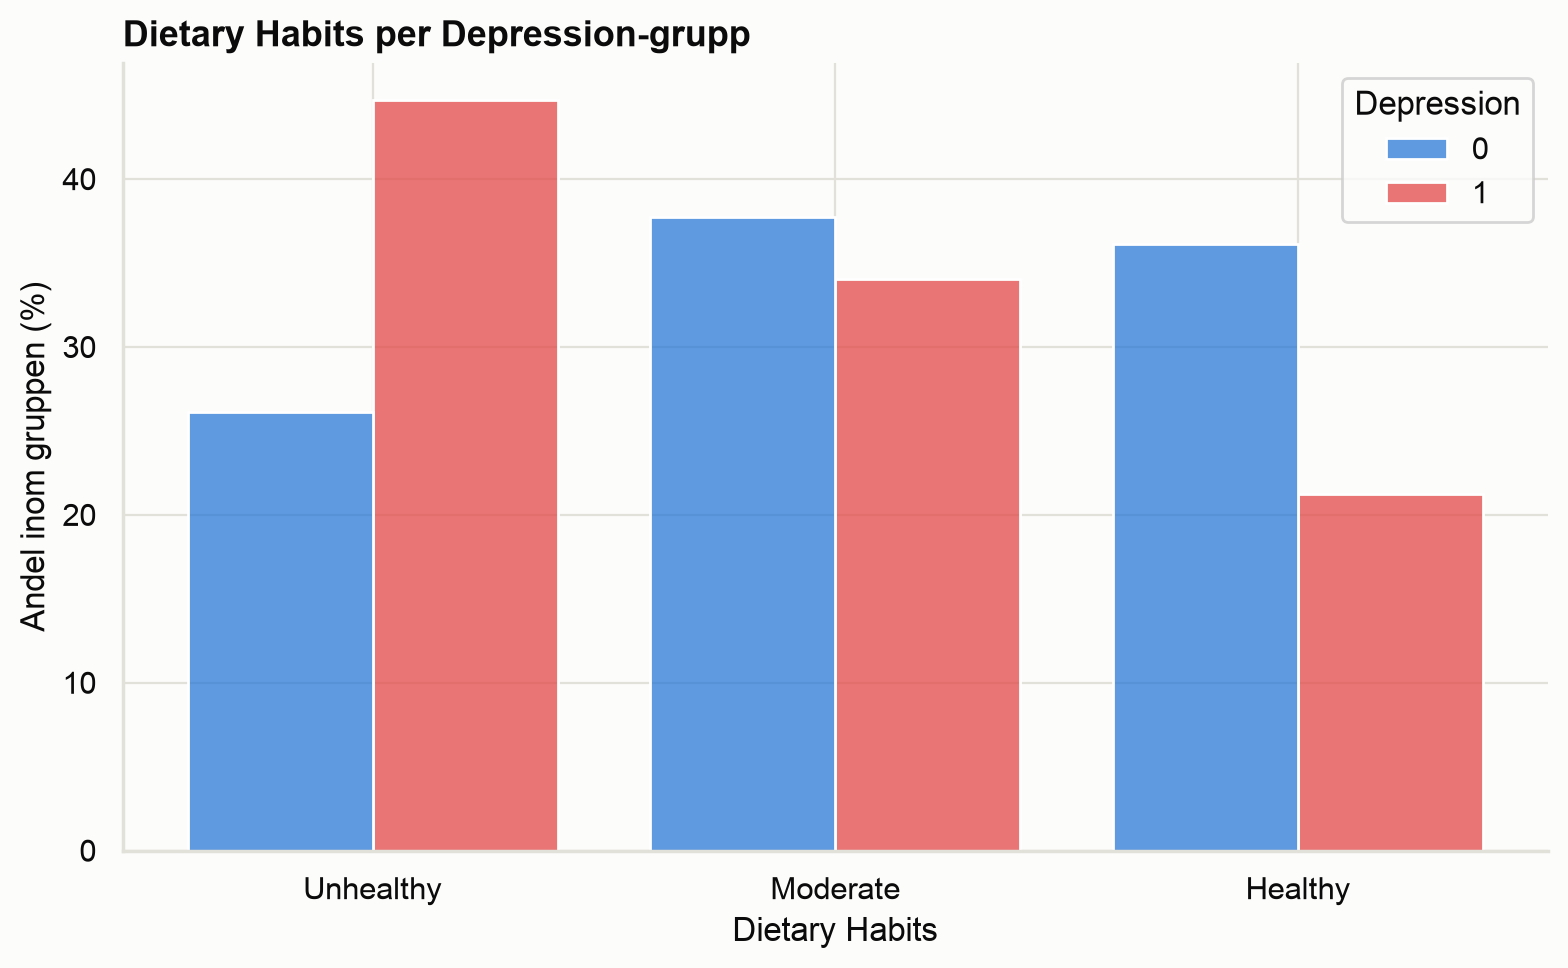

In [15]:
# Dietary Habits (1=Unhealthy, 2=Moderate, 3=Healthy): samma upplägg som Sleep Duration.
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=df, x="Dietary Habits", hue="Depression",
    stat="percent", common_norm=False, discrete=True, multiple="dodge", shrink=0.8,
    ax=ax,
)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(["Unhealthy", "Moderate", "Healthy"])
ax.set_ylabel("Andel inom gruppen (%)")
ax.set_title("Dietary Habits per Depression-grupp")
plt.tight_layout()
plt.show()

**Mönstret:** tydligare skevhet än Sleep Duration. Bland de UTAN depression äter en
majoritet Moderate/Healthy (37.8% / 36.2%), bara 26.1% Unhealthy. Bland de MED
depression är det omvänt: 44.7% äter Unhealthy, bara 21.3% Healthy. Det här är den
tydligaste visuella skillnaden av de fyra i denna sektion.

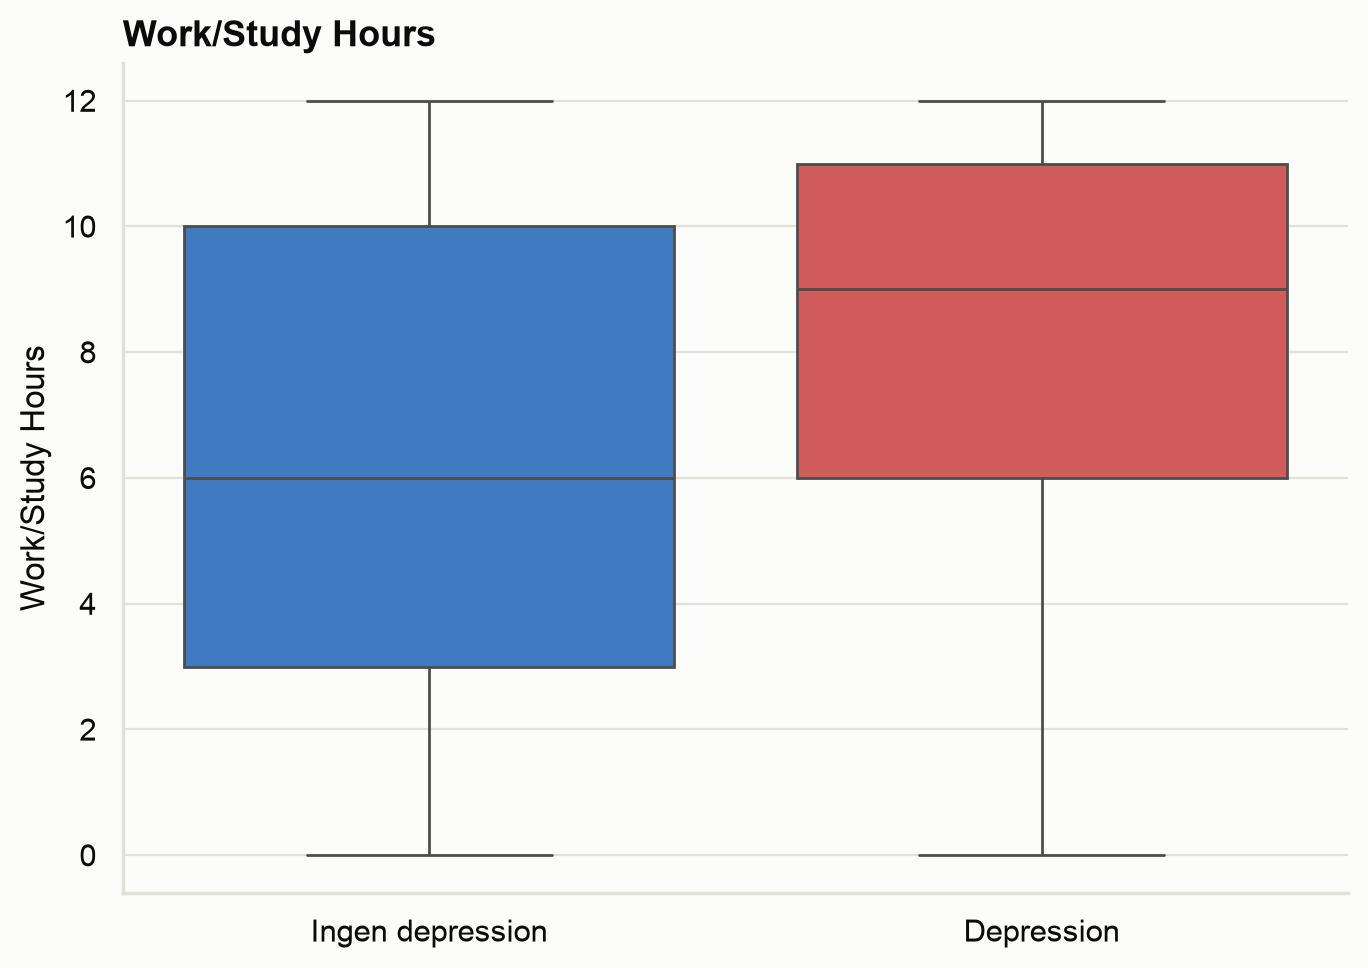

In [16]:
# Work/Study Hours: boxplot per Depression-grupp - samma stil som Academic Pressure/
# Financial Stress i Sektion 6.
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="Depression", y="Work/Study Hours", hue="Depression", legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Ingen depression", "Depression"])
ax.set_xlabel("")
ax.set_title("Work/Study Hours")
plt.tight_layout()
plt.show()

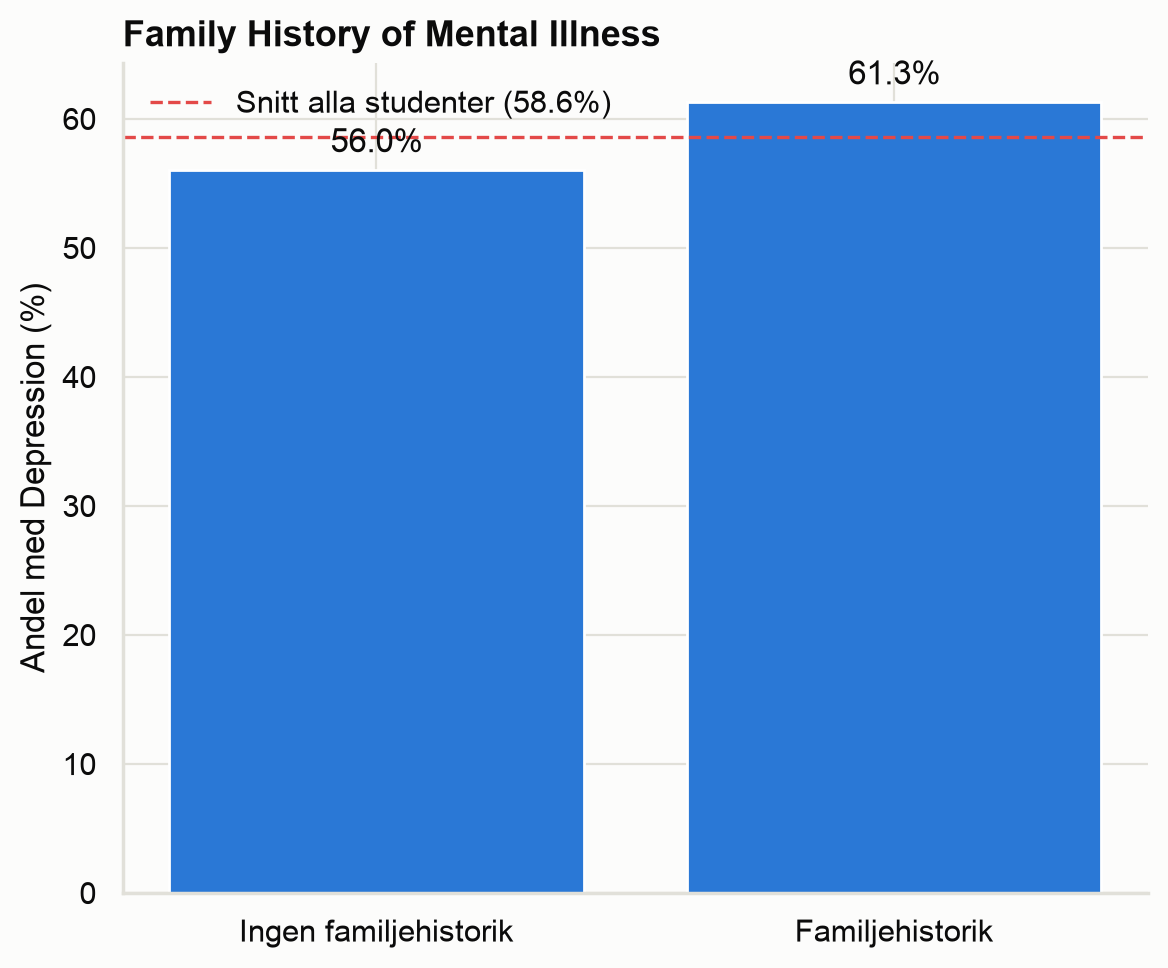

In [17]:
# Family History (0=No, 1=Yes): andel MED depression inom varje grupp (normalize per grupp).
rate_by_history = df.groupby("Family History of Mental Illness")["Depression"].mean()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(
    ["Ingen familjehistorik", "Familjehistorik"],
    rate_by_history.values * 100,
    color=PALETTE["blue"],  # en serie, en färg (samma princip som MI-diagrammet tidigare)
)
ax.bar_label(bars, fmt="%.1f%%", padding=4, color=PALETTE["ink"])
# Referenslinje för hela datasetets snittnivå - gör det lättare att se om en grupp
# ligger över/under genomsnittet.
ax.axhline(df["Depression"].mean() * 100, color=PALETTE["red"], linestyle="--", linewidth=1.2,
           label=f"Snitt alla studenter ({df['Depression'].mean()*100:.1f}%)")
ax.set_ylabel("Andel med Depression (%)")
ax.set_title("Family History of Mental Illness")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Mönstret:** liten men konsekvent skillnad - 56.0% depression utan familjehistorik mot
61.3% med, båda nära det totala snittet (58.6%). Svagast av de fyra i denna sektion.

## 8. Age & Study Satisfaction

Två variabler som föll mellan stolarna när vi läste av heatmapen. Age har korrelation
-0.23 mot Depression - starkare än samtliga livsstilsvariabler vi tittat på i Sektion 6-7 -
och Study Satisfaction ligger på -0.17. Båda är negativa, alltså: högre värde hänger ihop
med *lägre* andel depression.

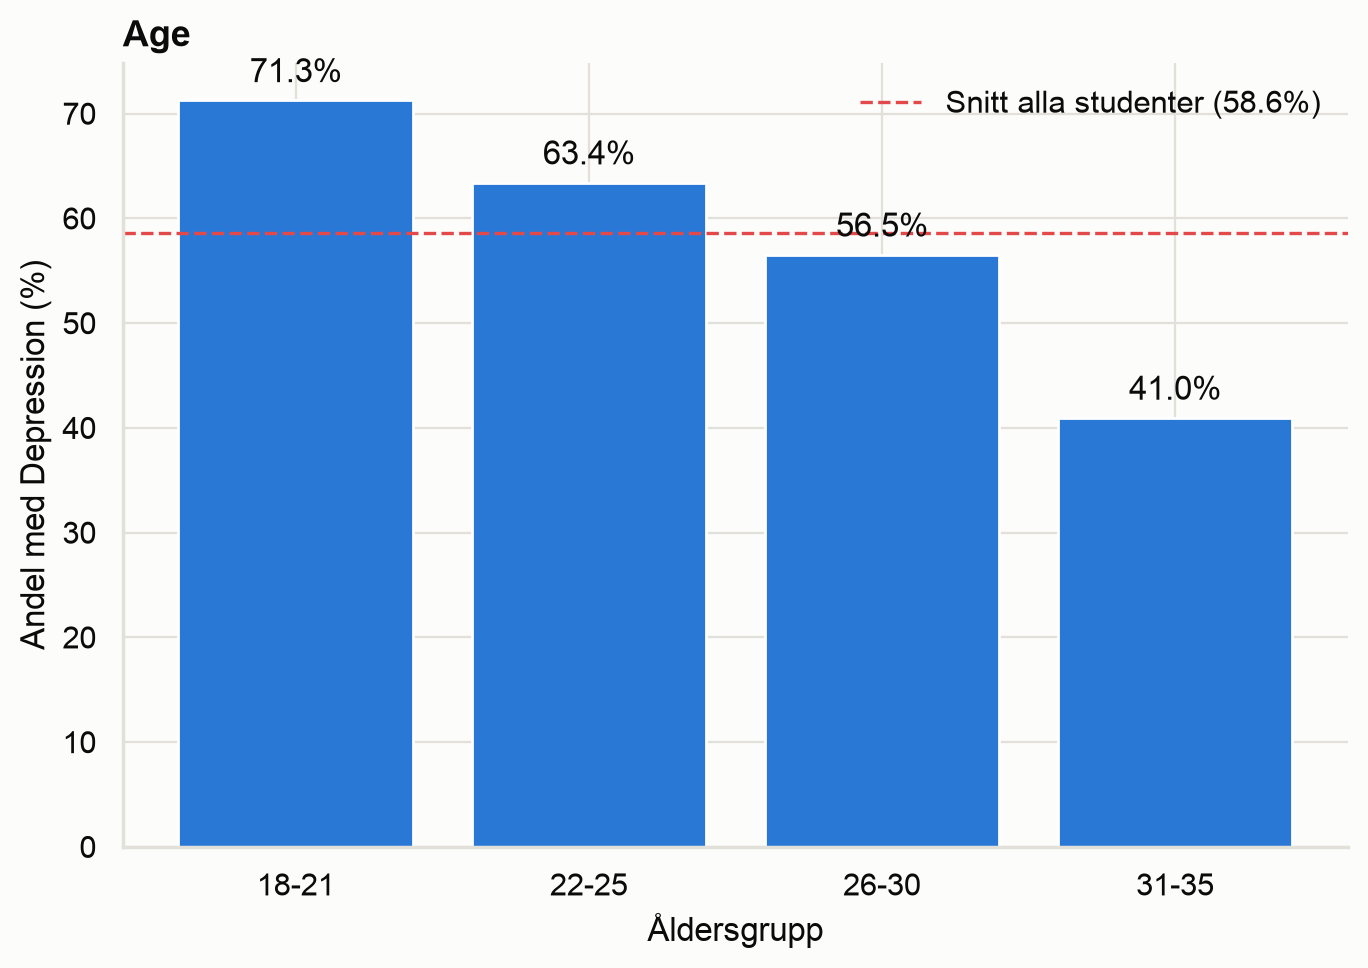

In [18]:
# Age är kontinuerlig (18-59) - vi delar in i grupper för att kunna jämföra andelar.
# De 39 studenter som är äldre än 35 hamnar utanför indelningen och faller bort, då
# gruppen är för liten (0.1% av datan) för att ge en tillförlitlig andel.
alders_grupper = pd.cut(df["Age"], bins=[17, 21, 25, 30, 35],
                        labels=["18-21", "22-25", "26-30", "31-35"])
andel_per_alder = df.groupby(alders_grupper, observed=True)["Depression"].mean() * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(andel_per_alder.index.astype(str), andel_per_alder.values, color=PALETTE["blue"])
ax.bar_label(bars, fmt="%.1f%%", padding=4, color=PALETTE["ink"])
ax.axhline(df["Depression"].mean() * 100, color=PALETTE["red"], linestyle="--", linewidth=1.2,
           label=f"Snitt alla studenter ({df['Depression'].mean()*100:.1f}%)")
ax.set_ylabel("Andel med Depression (%)")
ax.set_xlabel("Åldersgrupp")
ax.set_title("Age")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Mönstret:** en tydlig och jämn nedgång med stigande ålder - 71.3% bland de yngsta
(18-21) ned till 41.0% bland de äldsta (31-35). Det är den största spridningen vi sett
för en enskild variabel utanför Suicidal thoughts, och till skillnad från Sleep Duration
går den åt samma håll hela vägen utan hopp. Age är dessutom en av få variabler där
korrelationsmåttet (-0.23) inte underskattar mönstret nämnvärt, just eftersom sambandet
är så regelbundet.

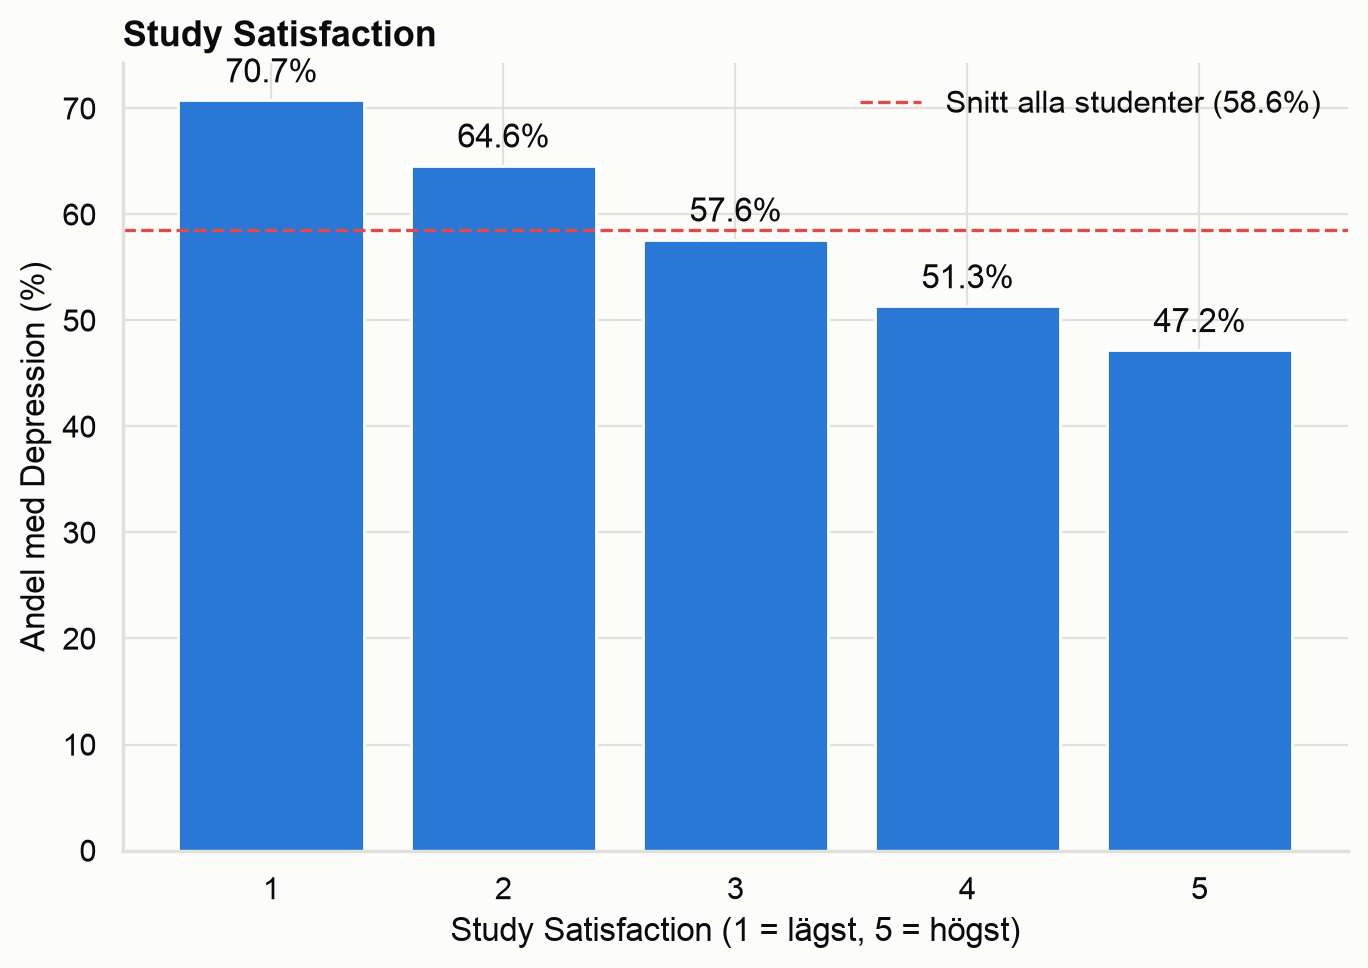

In [19]:
# Study Satisfaction (skala 0-5). Nivå 0 utelämnas - bara 10 studenter, för få för en
# tillförlitlig andel.
satisfaction = df[df["Study Satisfaction"] > 0]
andel_per_satisfaction = satisfaction.groupby("Study Satisfaction")["Depression"].mean() * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(andel_per_satisfaction.index.astype(int).astype(str),
              andel_per_satisfaction.values, color=PALETTE["blue"])
ax.bar_label(bars, fmt="%.1f%%", padding=4, color=PALETTE["ink"])
ax.axhline(df["Depression"].mean() * 100, color=PALETTE["red"], linestyle="--", linewidth=1.2,
           label=f"Snitt alla studenter ({df['Depression'].mean()*100:.1f}%)")
ax.set_ylabel("Andel med Depression (%)")
ax.set_xlabel("Study Satisfaction (1 = lägst, 5 = högst)")
ax.set_title("Study Satisfaction")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Mönstret:** en jämn nedgång från 70.7% vid lägsta nöjdhet till 47.2% vid högsta -
svagare än Age, men lika regelbunden och i förväntad riktning: ju nöjdare med studierna,
desto lägre andel depression.

## 9. Slutsatser

**Målvariabelns balans.** 58.6% med Depression / 41.4% utan – rimligt balanserat. Vi
behöver troligen ingen särskild balanseringsteknik (t.ex. SMOTE) inför modellering.

**Rangordning efter korrelation med Depression** (se stapeldiagrammet i Sektion 5):

| Variabel | Korrelation | Kommentar |
|---|---|---|
| Suicidal thoughts | 0.55 | Exkluderas, se nedan |
| Academic Pressure | 0.47 | Starkast av de användbara |
| Financial Stress | 0.36 | |
| **Age** | **-0.23** | Starkare än alla livsstilsvariabler |
| Work/Study Hours | 0.21 | |
| Dietary Habits | -0.21 | |
| **Study Satisfaction** | **-0.17** | |
| Sleep Duration | -0.09 | Svag, och mönstret är oregelbundet |
| Family History | 0.05 | |
| CGPA | 0.02 | I praktiken irrelevant |
| Gender | 0.00 | I praktiken irrelevant |

**Suicidal thoughts exkluderas från modelleringen i steg 4** – inom vården räknas
suicidtankar ofta som en del av själva depressionsdiagnosen, inte bara något som råkar
hänga ihop med den. Att ha med den som variabel hade mest mätt hur bra ett symptom kan
förutsäga sin egen diagnos, inte gett en modell som faktiskt förutsäger något nytt.

**Bekräftat visuellt (Sektion 6-8).**
- Academic Pressure och Financial Stress: samma medianskillnad (2 vs 4), men Academic
  Pressure visar en tydligare skillnad mellan grupperna.
- **Age: 71.3% (18-21) ned till 41.0% (31-35)** - den jämnaste och största nedgången av
  alla enskilda variabler vi tittat på.
- Dietary Habits: 44.7% äter Unhealthy i depressionsgruppen, mot 26.1% i den andra.
- **Study Satisfaction: 70.7% (nivå 1) ned till 47.2% (nivå 5)** - jämn och i förväntad
  riktning.
- Work/Study Hours: median 6h (ingen depression) vs 9h (depression).
- Sleep Duration: svagare och mindre regelbunden - depressionsgruppen sover oftare mindre
  (32.8% sover <5h, mot 18.9% som sover >8h), men mönstret hoppar.

**Svaga/oviktiga variabler.** CGPA (0.02) och Gender (0.00) verkar i praktiken sakna
betydelse. Family History ger också en svag skillnad (56.0% vs 61.3%, båda nära
totalsnittet 58.6%).

**Implikationer för nästa steg.**
- **Age bör vara med i supervised-modellerna i steg 4** trots att den inte är en
  livsstilsvariabel och därför inte ingår i klustringen (steg 3). Den är starkare kopplad
  till Depression än samtliga livsstilsvariabler, och sambandet är regelbundet.
- **Study Satisfaction bör också vara med** - svagare än Age, men jämn och i logisk
  riktning.
- Academic Pressure, Financial Stress, Work/Study Hours, Dietary Habits och Sleep Duration
  handlar alla om livsstil och är kandidater till klustringssteget (steg 3).
- Numeriska variabler behöver **skalas** (t.ex. StandardScaler) innan PCA/klustring, eftersom
  de har olika stora talintervall (Age 18-59 mot Dietary Habits 1-3) och annars skulle
  dominera resultatet utan att faktiskt vara viktigare.
- Suicidal thoughts exkluderas helt från modelleringen i steg 4, av skälet ovan. CGPA och
  Gender är kandidater att nedprioritera.